In [2]:
import json
import os

import pandas as pd

# Plot the accuracy 

dir = '../data/results/experiments/clustering_experiment_7'
dir2 = '../data/results/experiments/clustering_experiment_8'

errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])
complexity_df = pd.read_csv(os.path.join(dir, 'complexity.csv')).drop(columns=['Unnamed: 0'])
runtime_df = pd.read_csv(os.path.join(dir, 'runtime.csv')).drop(columns=['Unnamed: 0'])
with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

perfect_err = pd.read_csv(os.path.join(dir2, 'errors.csv')).drop(columns=['Unnamed: 0'])
perfect_run = pd.read_csv(os.path.join(dir2, 'runtime.csv')).drop(columns=['Unnamed: 0'])

print(config)

perfect_run


{'wknn_k': 2, 'rf_param': 'rsrq', 'operator_choice': [1, 10, 50, 88], 'cluster_range': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'n_runs': 10, 'campaigns': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'runtime': 3781.5134892463684}


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,44.106243,31.670167,27.264030,24.677916,26.050650,24.359458,24.710819,23.277708,22.797148,22.698556,22.502068,24.397921,22.544056,21.951371,22.111503,21.795118,21.718828,21.341335,21.904818,21.829822
1,44.947478,32.340317,27.957189,24.991501,26.446177,24.780046,24.501844,22.946016,23.018979,23.261279,23.275795,24.638028,22.088752,22.389154,22.394891,22.089898,22.163958,22.316818,22.008726,22.353924
2,41.853697,30.304646,27.476689,24.361382,25.697773,24.709343,24.777133,23.188161,22.855697,23.132948,22.671578,24.172641,22.632685,22.254077,22.502556,22.428689,22.398839,22.009735,21.200132,21.660138
3,41.505660,28.931950,29.814447,24.162422,25.655947,24.408654,24.630485,22.747260,22.874243,23.146715,23.278173,25.128659,22.854421,22.216153,22.098440,21.652742,21.724363,21.892452,21.670093,21.562614
4,41.937231,31.349419,26.139246,24.812645,25.082595,24.078390,24.951484,24.154309,22.707552,22.415719,22.909125,22.771212,21.809139,21.738836,22.273330,21.810462,21.567912,21.452720,22.210981,21.697462
5,42.013463,31.149020,26.399206,25.197248,25.264401,24.446214,24.676655,24.139016,23.268484,22.526813,22.378930,22.250566,22.142287,22.214649,22.043448,22.015452,21.990031,21.695633,22.065418,21.835123
6,42.591857,31.565273,26.941124,25.044893,24.788644,24.006952,25.348484,24.028363,23.020222,23.156119,22.909797,21.996848,21.970659,22.378979,22.727762,21.848061,21.840656,21.795385,22.297934,21.797834
7,43.738127,30.955518,26.797680,25.136876,25.013954,23.250340,24.540408,24.273034,23.133477,22.152144,22.811085,22.453176,22.187495,22.277624,22.663090,22.232132,22.274730,21.973903,22.300030,21.467729
8,43.806803,30.869581,25.572355,25.130432,24.332013,25.236800,23.595709,24.316675,23.302860,22.835572,23.114368,22.340669,22.037694,21.985544,21.264242,21.619211,21.488484,22.190092,21.384894,21.175359
9,42.717516,29.873880,25.220236,24.513997,23.963154,24.689230,23.015024,23.780421,22.521176,22.560046,22.570455,22.398445,22.088531,21.940877,21.186091,21.326660,21.394022,21.925183,21.388160,20.931778


In [3]:
cluster_columns = [col for col in errors_df.columns]

melted_error_df = pd.melt(errors_df, value_vars=cluster_columns,
                          var_name='clusters', value_name='error')

melted_perfect_err = pd.melt(perfect_err, value_vars=cluster_columns, var_name='clusters', value_name='error')

melted_perfect_err['classification'] = 'Perfect'
melted_error_df['classification'] = 'RandomForest'

error = pd.concat([melted_error_df, melted_perfect_err], axis=0, ignore_index=True)

melted_complexity_df = pd.melt(complexity_df, value_vars=cluster_columns,
                               var_name='clusters', value_name='complexity')

melted_runtime_df = pd.melt(runtime_df, value_vars=cluster_columns, var_name='clusters', value_name='runtime')

melted_complexity_df['complexity'] = melted_complexity_df['complexity'].astype(int)

merged = pd.merge(melted_error_df, melted_complexity_df, on='clusters', how='left')
merged = pd.merge(merged, melted_runtime_df, on='clusters', how='left')

error

,clusters,error,classification
0,1,2.703714,RandomForest
1,1,2.666754,RandomForest
2,1,2.735989,RandomForest
3,1,2.686612,RandomForest
4,1,2.675027,RandomForest
...,...,...,...
395,20,3.010741,Perfect
396,20,3.119553,Perfect
397,20,3.209603,Perfect
398,20,3.096319,Perfect


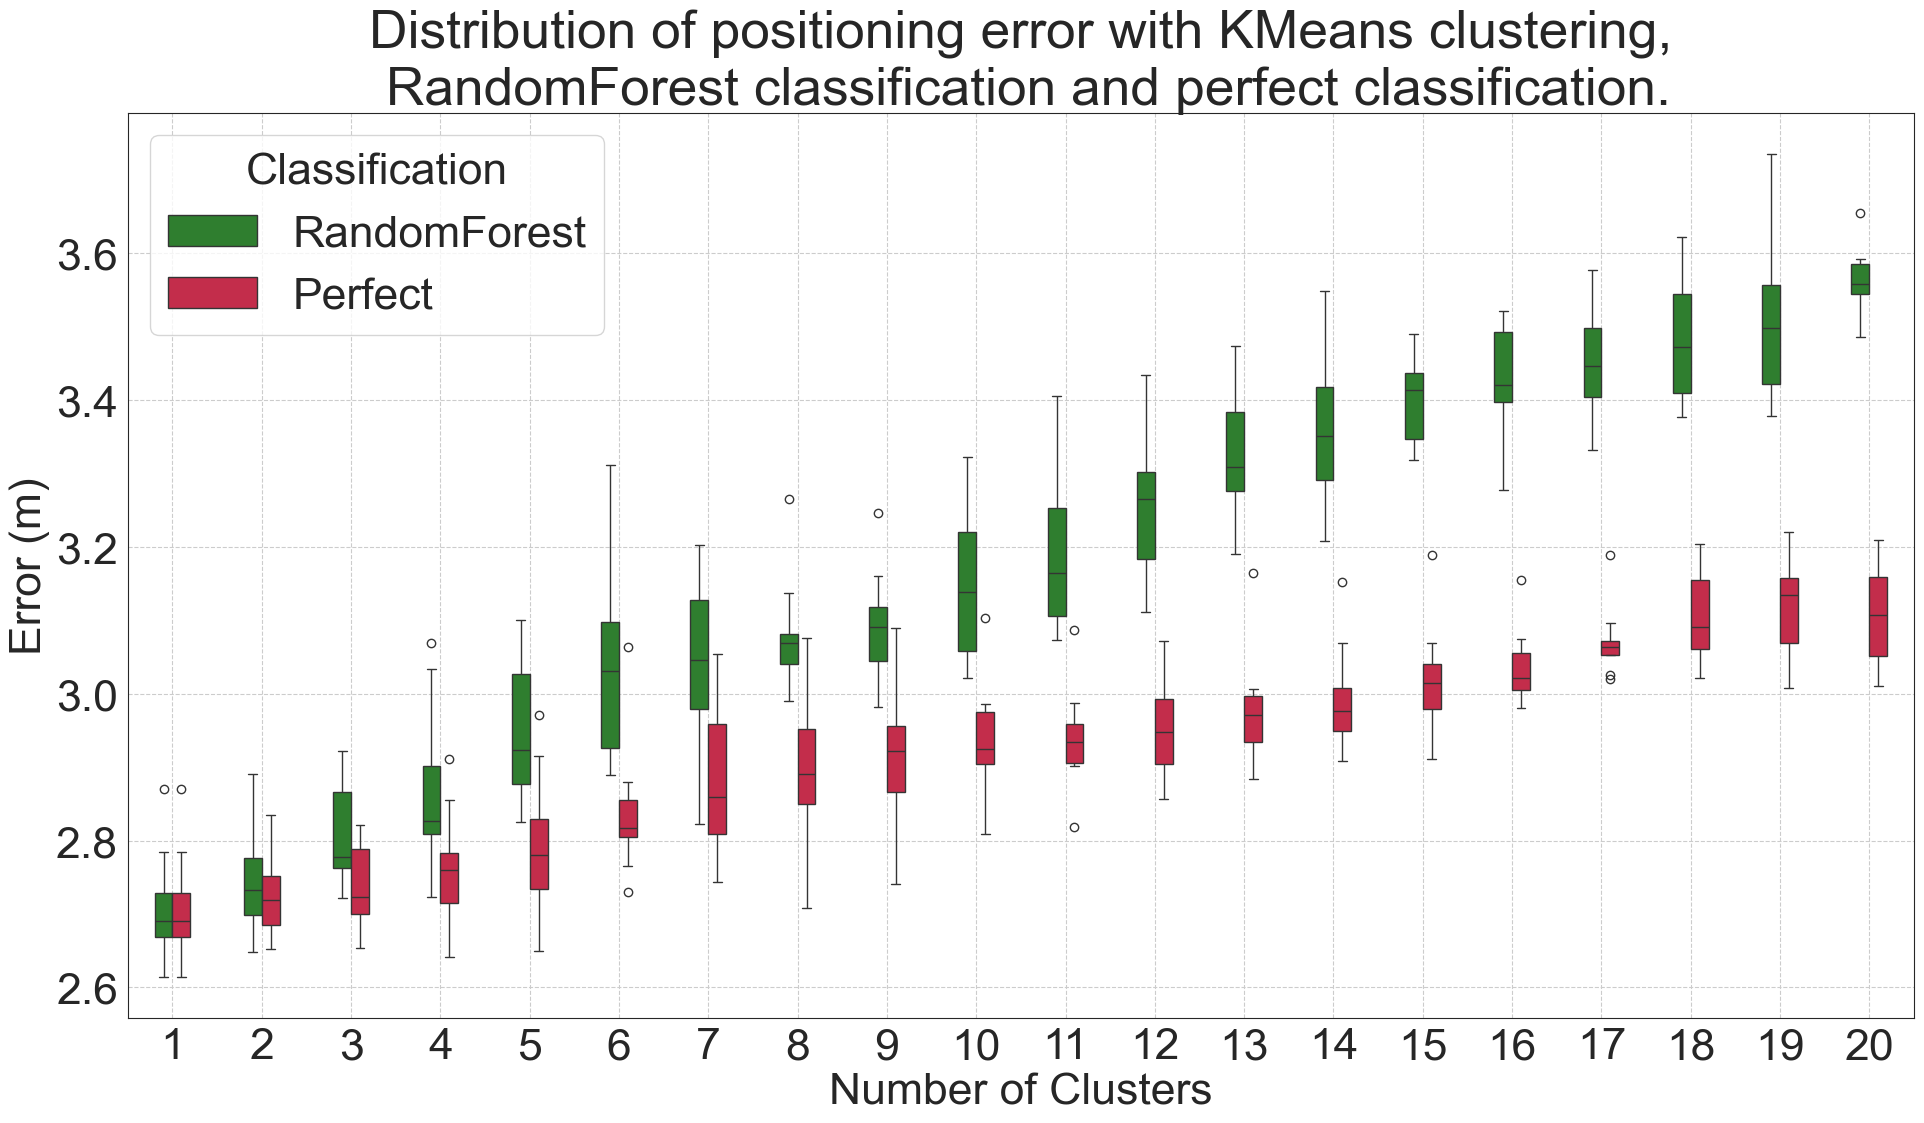

In [4]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rcParams.update({"font.size": 32})


def plot_data(df: pd.DataFrame, x_label: str, y_label: str, x: str, y: str, title: str, color: str, hue: str):
    # Set the style to white background
    plt.figure(figsize=(20, 12))
    sns.set_style("white")

    palette = ['forestgreen', 'crimson']
    # Create the boxplot using seaborn
    sns.boxplot(x=x, y=y, data=df, width=0.4, hue=hue, palette=palette, dodge=True)

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(title='Classification')

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    def thousands_formatter(x, pos):
        return f'{x / 1000:,.0f}K'.replace(',', ' ').replace('.', ',')

    if y == 'complexity':
        plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    elif y == 'runtime':
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    else:
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Show the plot
    plt.tight_layout()
    plt.show()


# Example usage
plot_data(
    df=error,
    x='clusters',
    y='error',
    x_label='Number of Clusters',
    y_label='Error (m)',
    title='Distribution of positioning error with KMeans clustering,\n RandomForest classification and perfect classification.',
    color='forestgreen',
    hue='classification',
)

# plot_data(
#     df=merged,
#     x='clusters',
#     y='runtime',
#     x_label='Number of Clusters',
#     y_label='Runtime (ms/TP)',
#     title='Boxplot of Runtime for KMeans and Random Forest',
#     color='skyblue'
# )


In [11]:

def print_increase(key: str):
    print(f'{key}')
    print('Measurement\tPercentage\tValue')
    means = merged.groupby('clusters')['runtime'].mean()
    r10 = (means['1'] - means[key]) / means['1'] * 100
    d10 = means['1'] - means[key]

    print(f'runtime\t\t{r10:.1f}\t\t{d10:.1f}')
    print('----------------------------')

    means = merged.groupby('clusters')['error'].mean()

    r10 = (means[key] - means['1']) / means['1'] * 100
    d10 = means[key] - means['1']

    print(f'error\t\t{r10:.1f}\t\t{d10:.1f}')
    print('----------------------------')


print_increase('2')
print_increase('10')
print_increase('20')

2
Measurement	Percentage	Value
runtime		28.2		4.4
----------------------------
error		1.4		0.0
----------------------------
10
Measurement	Percentage	Value
runtime		44.4		6.9
----------------------------
error		16.4		0.4
----------------------------
20
Measurement	Percentage	Value
runtime		45.8		7.2
----------------------------
error		31.6		0.9
----------------------------


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_28639/3644375943.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x, y=y, data=df, palette=palette)
/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_28639/3644375943.py:8: UserWarning: 
The palette list has fewer values (1) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x=x, y=y, data=df, palette=palette)


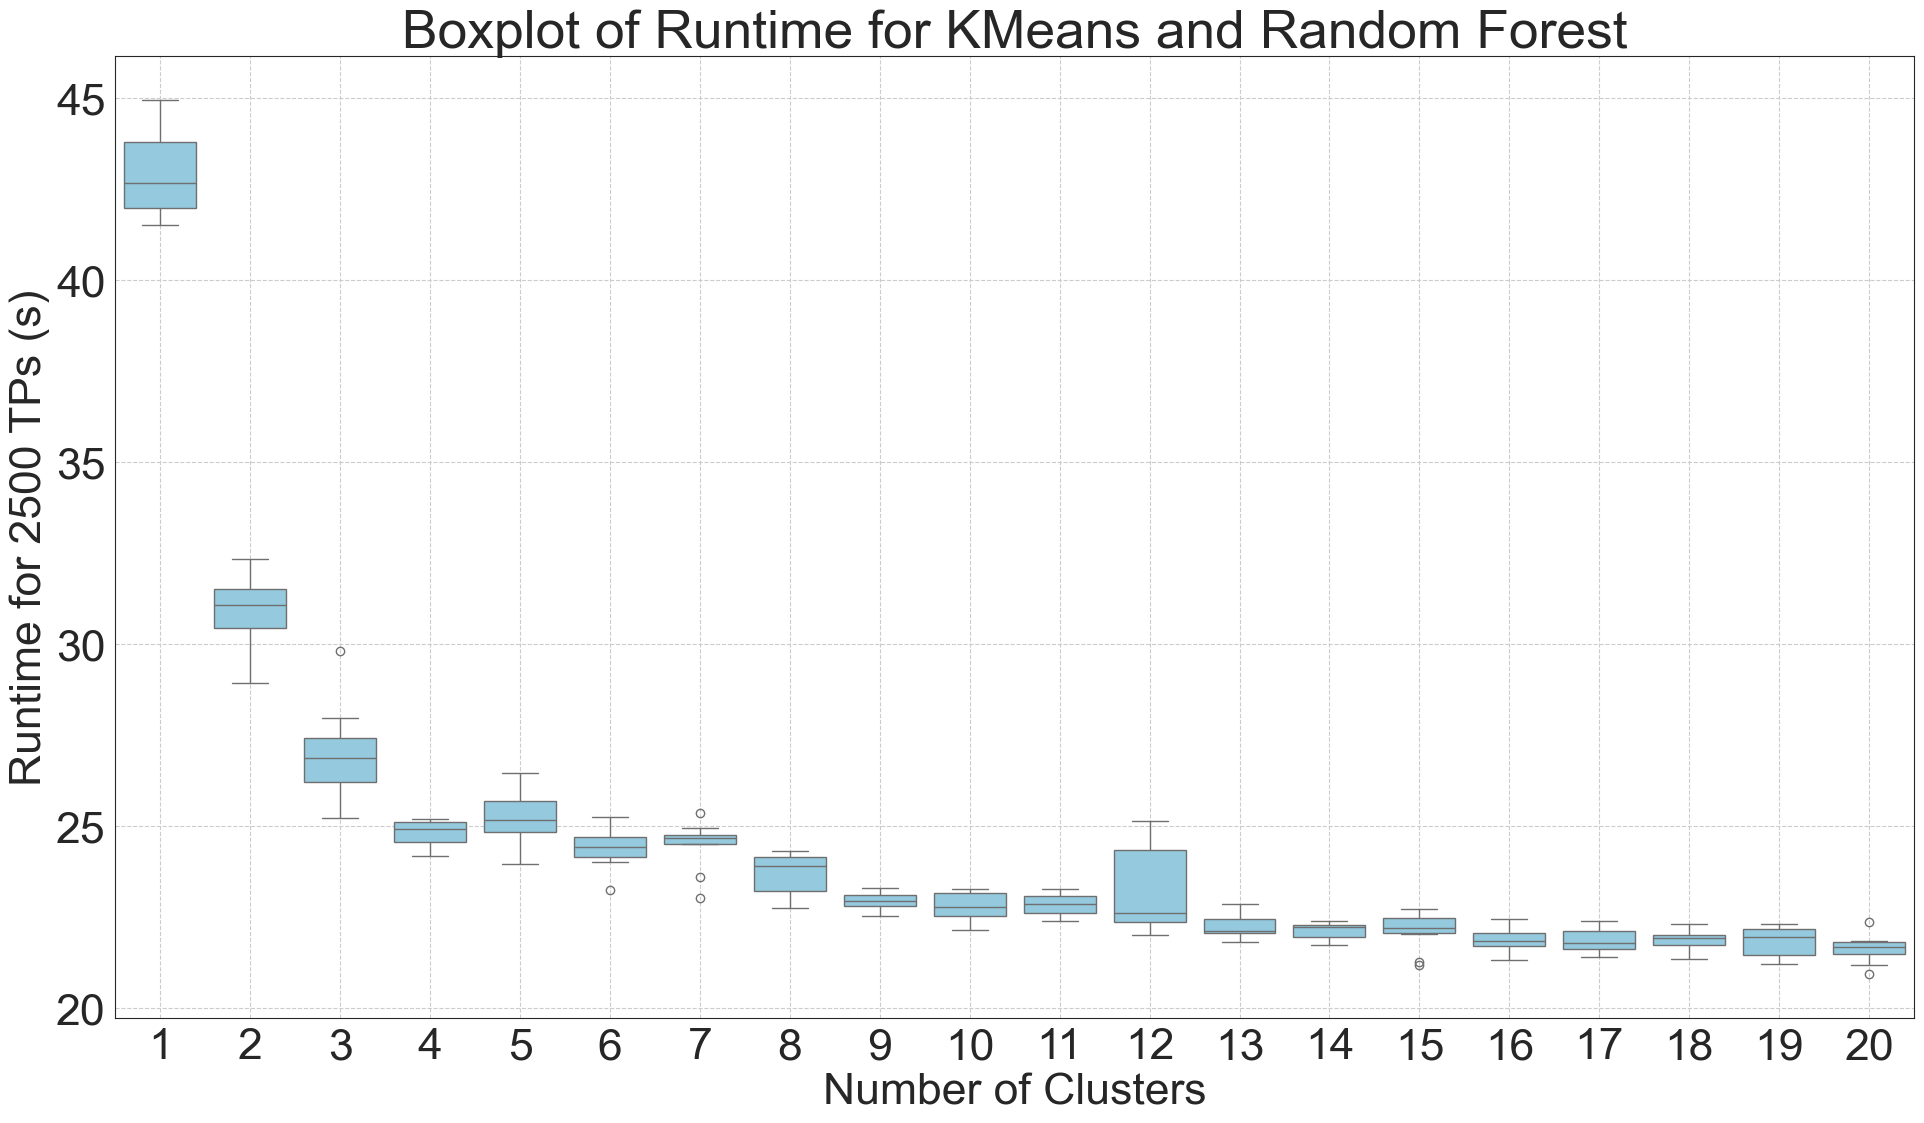

Reduction with 2 clusters:  28.006347237825825 %, in meters ->  12.020830445700263
Reduction with 10 clusters:  46.90672985583002 %, in meters ->  20.133216287400863
Reduction with 20 clusters:  49.60329101052034 %, in meters ->  21.29062907499974


In [46]:

def plot_data(df: pd.DataFrame, x_label: str, y_label: str, x: str, y: str, title: str, color: str, hue: str):
    # Set the style to white background
    plt.figure(figsize=(20, 12))
    sns.set_style("white")

    palette = ['skyblue']
    # Create the boxplot using seaborn
    sns.boxplot(x=x, y=y, data=df, palette=palette)

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    def thousands_formatter(x, pos):
        return f'{x / 1000:,.0f}K'.replace(',', ' ').replace('.', ',')

    if y == 'complexity':
        plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    elif y == 'runtime':
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    else:
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Show the plot
    plt.tight_layout()
    plt.show()


melted_runtime_df = pd.melt(perfect_run, value_vars=cluster_columns, var_name='clusters', value_name='runtime')

plot_data(
    df=melted_runtime_df,
    x='clusters',
    y='runtime',
    x_label='Number of Clusters',
    y_label='Runtime for 2500 TPs (s)',
    title='Boxplot of Runtime for KMeans and Random Forest',
    color='skyblue',
    hue=None
)

means = melted_runtime_df.groupby('clusters')['runtime'].mean()

r2 = (means['1'] - means['2']) / means['1'] * 100
d2 = means['1'] - means['2']

r20 = (means['1'] - means['20']) / means['1'] * 100
d20 = means['1'] - means['20']

r10 = (means['1'] - means['10']) / means['1'] * 100
d10 = means['1'] - means['10']

print('Reduction with 2 clusters: ', r2, '%, in meters -> ', d2)
print('Reduction with 10 clusters: ', r10, '%, in meters -> ', d10)
print('Reduction with 20 clusters: ', r20, '%, in meters -> ', d20)